1) First 5 rows:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  

2) Shape (rows, cols): (150, 5)

2) describe():
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000 

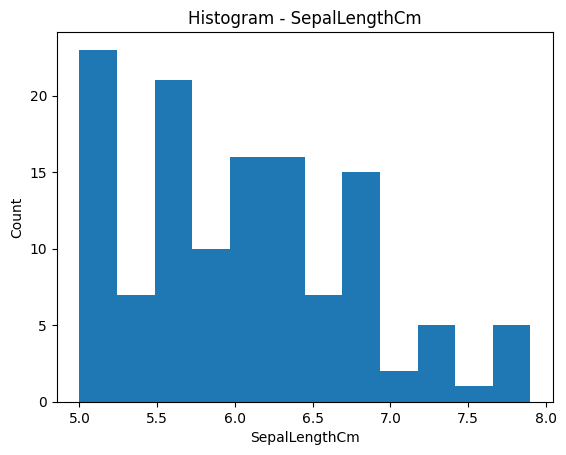

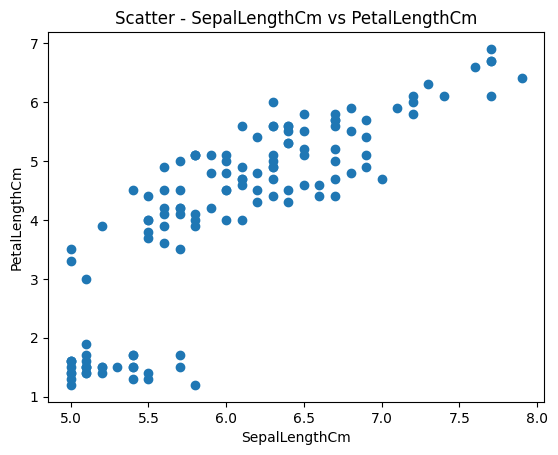

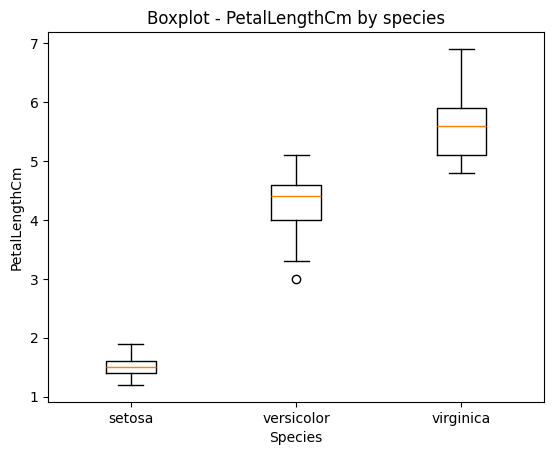

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris

# =========================
# 1) Load Iris dataset + show first 5 rows
# =========================
iris = load_iris(as_frame=True)
df = iris.frame  # includes features + target

# Convert numeric target to species names
df["species"] = df["target"].map(dict(enumerate(iris.target_names)))
df.drop(columns=["target"], inplace=True)

print("1) First 5 rows:")
print(df.head())

# =========================
# 2) Shape + describe()
# =========================
print("\n2) Shape (rows, cols):", df.shape)
print("\n2) describe():")
print(df.describe())

# =========================
# 3) Rename columns to clearer names
# =========================
df.rename(columns={
    "sepal length (cm)": "SepalLengthCm",
    "sepal width (cm)" : "SepalWidthCm",
    "petal length (cm)": "PetalLengthCm",
    "petal width (cm)" : "PetalWidthCm",
}, inplace=True)

print("\n3) Column names after rename:")
print(df.columns)

# =========================
# 4) Add a ratio column: petal length / petal width
# =========================
df["PetalLengthWidthRatio"] = df["PetalLengthCm"] / df["PetalWidthCm"]

print("\n4) Example of the new ratio column:")
print(df[["PetalLengthCm", "PetalWidthCm", "PetalLengthWidthRatio"]].head())

# =========================
# 5) Drop a "non-useful" column (example: drop the ratio column)
# =========================
df_dropped = df.drop(columns=["PetalLengthWidthRatio"])
print("\n5) Columns after dropping PetalLengthWidthRatio:")
print(df_dropped.columns)

# =========================
# 6) Remove all rows where SepalLength < 5.0
# =========================
df_clean = df_dropped[df_dropped["SepalLengthCm"] >= 5.0].copy()

print("\n6) Shape before/after filtering SepalLengthCm >= 5.0:")
print("Before:", df_dropped.shape, "After:", df_clean.shape)

# =========================
# 7) Filter only the 'setosa' species
# =========================
df_setosa = df_clean[df_clean["species"] == "setosa"].copy()

print("\n7) Number of setosa rows after cleaning:", len(df_setosa))
print(df_setosa.head())

# =========================
# 8) Count how many samples per species
# =========================
counts = df_clean["species"].value_counts()

print("\n8) Samples per species:")
print(counts)

# =========================
# 9) Visualizations:
#    (1) Histogram, (2) Scatter plot, (3) Boxplot by species
# =========================

# (1) Histogram for one variable
plt.figure()
plt.hist(df_clean["SepalLengthCm"], bins=12)
plt.title("Histogram - SepalLengthCm")
plt.xlabel("SepalLengthCm")
plt.ylabel("Count")
plt.show()

# (2) Scatter plot between two variables
plt.figure()
plt.scatter(df_clean["SepalLengthCm"], df_clean["PetalLengthCm"])
plt.title("Scatter - SepalLengthCm vs PetalLengthCm")
plt.xlabel("SepalLengthCm")
plt.ylabel("PetalLengthCm")
plt.show()

# (3) Boxplot comparing species (example: PetalLengthCm)
data_for_box = [
    df_clean[df_clean["species"] == sp]["PetalLengthCm"].values
    for sp in ["setosa", "versicolor", "virginica"]
]

plt.figure()
plt.boxplot(data_for_box, tick_labels=["setosa", "versicolor", "virginica"])
plt.title("Boxplot - PetalLengthCm by species")
plt.xlabel("Species")
plt.ylabel("PetalLengthCm")
plt.show()
